In [1]:
!pip install pycaret==3.3.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.1/486.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.4 M

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.datasets import load_iris, load_digits
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

In [3]:
# Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names

scaler = StandardScaler()
X_iris_sc = scaler.fit_transform(X_iris)

print('Iris:', X_iris.shape, 'clases:', np.unique(y_iris))

# MNIST (digits)
digits = load_digits()
X_dig = digits.data
y_dig = digits.target

X_dig_sc = StandardScaler().fit_transform(X_dig)

print('Digitos:', X_dig.shape, 'clases:', np.unique(y_dig))

Iris: (150, 4) clases: [0 1 2]
Digitos: (1797, 64) clases: [0 1 2 3 4 5 6 7 8 9]


In [4]:
from pycaret.clustering import setup, create_model, assign_model, plot_model, models

df_iris = pd.DataFrame(X_iris, columns=feature_names_iris)

# 1) setup: el parámetro normalize=True aplica StandardScaler internamente
clu_setup = setup(data=df_iris, normalize=True, session_id=42, verbose=False)

In [5]:
# Lista de modelos disponibles
models()

,Name,Reference
ID,,
kmeans,K-Means Clustering,sklearn.cluster._kmeans.KMeans
ap,Affinity Propagation,sklearn.cluster._affinity_propagation.Affinity...
meanshift,Mean Shift Clustering,sklearn.cluster._mean_shift.MeanShift
sc,Spectral Clustering,sklearn.cluster._spectral.SpectralClustering
hclust,Agglomerative Clustering,sklearn.cluster._agglomerative.AgglomerativeCl...
dbscan,Density-Based Spatial Clustering,sklearn.cluster._dbscan.DBSCAN
optics,OPTICS Clustering,sklearn.cluster._optics.OPTICS
birch,Birch Clustering,sklearn.cluster._birch.Birch


In [6]:
# 2) Crear un modelo K-Means con 3 clusters
kmeans_pc = create_model('kmeans', num_clusters=3)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4799,157.3602,0.7894,0,0,0


Processing:   0%|          | 0/3 [00:00<?, ?it/s]

In [7]:
# 3) Asignar las etiquetas al dataset
df_clustered = assign_model(kmeans_pc)
df_clustered.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,5.1,3.5,1.4,0.2,Cluster 1
1,4.9,3.0,1.4,0.2,Cluster 2
2,4.7,3.2,1.3,0.2,Cluster 2
3,4.6,3.1,1.5,0.2,Cluster 2
4,5.0,3.6,1.4,0.2,Cluster 1


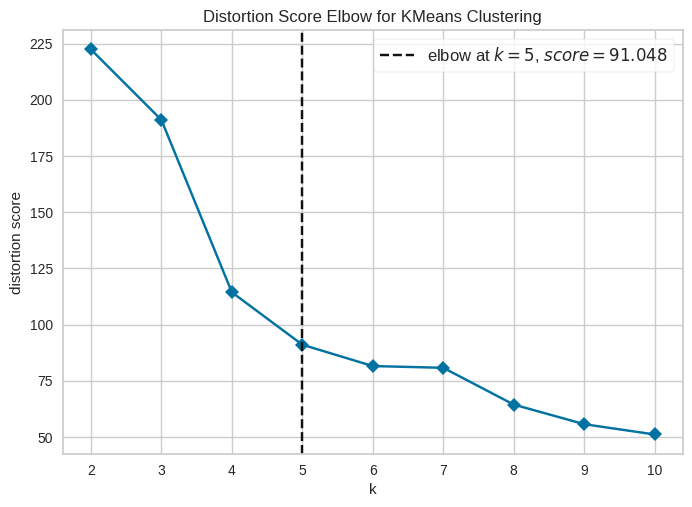

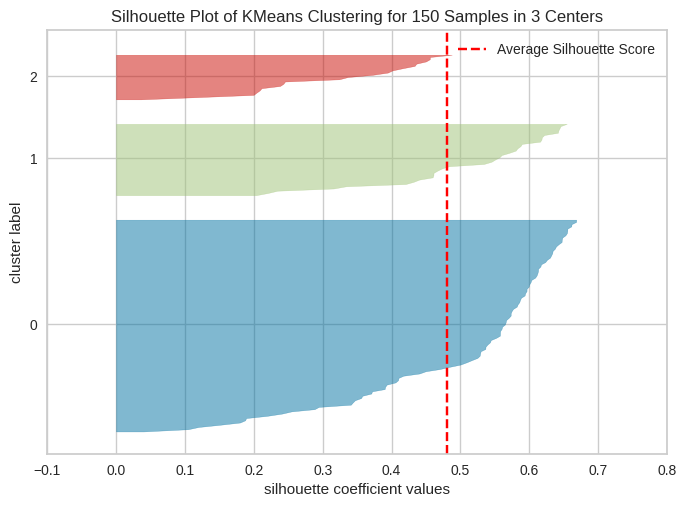

In [8]:
# Gráficos integrados de PyCaret
plot_model(kmeans_pc, plot='cluster')   # proyección 2D con PCA
plot_model(kmeans_pc, plot='elbow')     # método del codo
plot_model(kmeans_pc, plot='silhouette') # diagrama de silueta

In [11]:
from pycaret.anomaly import setup as ad_setup, create_model as ad_create, assign_model as ad_assign

ad_setup(data=df_iris, normalize=True, session_id=42, verbose=False)
iforest = ad_create('iforest')          # Isolation Forest
df_anom = ad_assign(iforest)
print('Anomalías detectadas:', (df_anom['Anomaly'] == 1).sum())
df_anom.head()

Processing:   0%|          | 0/3 [00:00<?, ?it/s]

Anomalías detectadas: 8


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Anomaly,Anomaly_Score
0,5.1,3.5,1.4,0.2,0,-0.183079
1,4.9,3.0,1.4,0.2,0,-0.157089
2,4.7,3.2,1.3,0.2,0,-0.136576
3,4.6,3.1,1.5,0.2,0,-0.127722
4,5.0,3.6,1.4,0.2,0,-0.172064


In [ ]:
Ejercicio 8
Usando PyCaret, compara K-Means con num_clusters desde 2 hasta 6. ¿Cuál ofrece la mejor silueta?
Crea un modelo 'gmm' con PyCaret y compáralo con 'kmeans' usando los gráficos integrados.
En el módulo de anomalías, prueba diferentes algoritmos ('iforest', 'knn', 'lof', 'svm') y compara cuántas anomalías detecta cada un